# ĐỒ ÁN KHAI PHÁ DỮ LIỆU
## Predict Students' Dropout and Academic Success

### Sinh viên thực hiện
- Nguyễn Dương Bảo Trân - 3123410386
- Giang Hào Tường - 3123410421

### Bài toán trên dataset 2
Dataset này được khai phá theo **2 hướng bài toán**:

**Bài toán 1: Phân loại (Classification)**  
Dự đoán tình trạng học tập cuối cùng của sinh viên thuộc một trong ba nhóm:
- Dropout
- Enrolled
- Graduate

**Bài toán 2: Phân tích kết hợp (Association Analysis)**  
Khai phá các luật kết hợp để tìm ra những tổ hợp đặc trưng thường xuất hiện cùng với nhóm **Dropout** hoặc **Graduate**, từ đó rút ra các mẫu dữ liệu điển hình trong học tập và tài chính của sinh viên.

### Hai câu hỏi khai phá dữ liệu
1. Những yếu tố nào ảnh hưởng nhiều nhất đến tình trạng học tập của sinh viên?
2. Có thể xây dựng mô hình dự đoán kết quả học tập của sinh viên đủ tốt để hỗ trợ nhà trường hay không?

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Đã import xong thư viện.")

Đã import xong thư viện.


### 1. Đọc dữ liệu và xem thông tin tổng quan

In [2]:
file_path = "data.csv"

df = pd.read_csv(file_path)

# nếu đọc ra 1 cột thì thử lại với dấu ;
if df.shape[1] == 1:
    df = pd.read_csv(file_path, sep=";")

print("Kích thước dữ liệu:", df.shape)
display(df.head())
df.info()
display(df.describe(include="all").T)

Kích thước dữ liệu: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance\t,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous qualification (grade),4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mother's qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Father's qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


### 2. Kiểm tra dữ liệu thiếu, dữ liệu trùng lặp và phân bố biến mục tiêu ban đầu

In [3]:
print("Số lượng giá trị thiếu theo từng cột:")
display(df.isnull().sum())

print("Số dòng trùng lặp:", df.duplicated().sum())

target_col = "Target" if "Target" in df.columns else df.columns[-1]

print("Tên cột mục tiêu:", target_col)
print("Phân bố biến mục tiêu:")
display(df[target_col].value_counts())
display((df[target_col].value_counts(normalize=True) * 100).round(2))

Số lượng giá trị thiếu theo từng cột:


Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

Số dòng trùng lặp: 0
Tên cột mục tiêu: Target
Phân bố biến mục tiêu:


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

### 3. Tiền xử lý dữ liệu: chuẩn hóa tên cột và làm sạch dữ liệu

In [4]:
data = df.copy()

data.columns = [
    col.strip()
       .lower()
       .replace("'", "")
       .replace("/", "_")
       .replace(" ", "_")
       .replace("(", "")
       .replace(")", "")
       .replace("-", "_")
    for col in data.columns
]

print("Tên cột sau khi chuẩn hóa:")
print(data.columns.tolist())

print("Số dòng trùng lặp trước khi xóa:", data.duplicated().sum())
data = data.drop_duplicates().copy()
print("Kích thước dữ liệu sau khi xóa trùng:", data.shape)

display(data.head())

Tên cột sau khi chuẩn hóa:
['marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening_attendance', 'previous_qualification', 'previous_qualification_grade', 'nacionality', 'mothers_qualification', 'fathers_qualification', 'mothers_occupation', 'fathers_occupation', 'admission_grade', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment', 'international', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp', 'target']
Số dòng trùng lặ

,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mothers_qualification,fathers_qualification,mothers_occupation,fathers_occupation,admission_grade,displaced,educational_special_needs,debtor,tuition_fees_up_to_date,gender,scholarship_holder,age_at_enrollment,international,curricular_units_1st_sem_credited,curricular_units_1st_sem_enrolled,curricular_units_1st_sem_evaluations,curricular_units_1st_sem_approved,curricular_units_1st_sem_grade,curricular_units_1st_sem_without_evaluations,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### 4. Xác định biến mục tiêu và tách dữ liệu mô hình

In [5]:
target_column = "target"

print("Các lớp của biến mục tiêu:")
display(data[target_column].value_counts())

X = data.drop(columns=[target_column])
y = data[target_column]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Các lớp của biến mục tiêu:


target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Kích thước X: (4424, 36)
Kích thước y: (4424,)


### 4.1. Rút trích đặc trưng phục vụ khai phá dữ liệu

In [6]:
eda_data = data.copy()

if "age_at_enrollment" in eda_data.columns:
    eda_data["age_group"] = pd.cut(
        eda_data["age_at_enrollment"],
        bins=[0, 18, 22, 26, 35, 100],
        labels=["<=18", "19-22", "23-26", "27-35", ">35"]
    )

if "admission_grade" in eda_data.columns:
    eda_data["admission_grade_group"] = pd.qcut(
        eda_data["admission_grade"],
        q=4,
        labels=["low", "medium", "high", "very_high"],
        duplicates="drop"
    )

if "curricular_units_1st_sem_approved" in eda_data.columns:
    eda_data["sem1_approved_group"] = pd.cut(
        eda_data["curricular_units_1st_sem_approved"],
        bins=[-1, 0, 3, 6, 20],
        labels=["0", "1-3", "4-6", "7+"]
    )

if "curricular_units_2nd_sem_approved" in eda_data.columns:
    eda_data["sem2_approved_group"] = pd.cut(
        eda_data["curricular_units_2nd_sem_approved"],
        bins=[-1, 0, 3, 6, 20],
        labels=["0", "1-3", "4-6", "7+"]
    )

if "curricular_units_1st_sem_grade" in eda_data.columns:
    eda_data["sem1_grade_group"] = pd.cut(
        eda_data["curricular_units_1st_sem_grade"],
        bins=[-1, 10, 12, 14, 20],
        labels=["low", "medium", "high", "very_high"]
    )

if "curricular_units_2nd_sem_grade" in eda_data.columns:
    eda_data["sem2_grade_group"] = pd.cut(
        eda_data["curricular_units_2nd_sem_grade"],
        bins=[-1, 10, 12, 14, 20],
        labels=["low", "medium", "high", "very_high"]
    )

show_cols = [col for col in [
    "target", "age_group", "admission_grade_group",
    "sem1_approved_group", "sem2_approved_group",
    "sem1_grade_group", "sem2_grade_group"
] if col in eda_data.columns]

display(eda_data[show_cols].head())

,target,age_group,admission_grade_group,sem1_approved_group,sem2_approved_group,sem1_grade_group,sem2_grade_group
0,Dropout,19-22,high,0,0,low,low
1,Graduate,19-22,very_high,4-6,4-6,high,high
2,Dropout,19-22,medium,0,0,low,low
3,Graduate,19-22,medium,4-6,4-6,high,high
4,Graduate,>35,very_high,4-6,4-6,high,high


### 5. Thống kê mô tả sau tiền xử lý

In [7]:
display(X.describe(include="all").T)

print("Phân bố target:")
display((y.value_counts(normalize=True) * 100).round(2))

,count,mean,std,min,25%,50%,75%,max
marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


Phân bố target:


target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

### 5.1. Mô tả chất lượng dữ liệu và phân bố lớp mục tiêu

,dtype,n_unique,missing,missing_pct
curricular_units_1st_sem_grade,float64,805,0,0.0
curricular_units_2nd_sem_grade,float64,786,0,0.0
admission_grade,float64,620,0,0.0
previous_qualification_grade,float64,101,0,0.0
fathers_occupation,int64,46,0,0.0
age_at_enrollment,int64,46,0,0.0
curricular_units_1st_sem_evaluations,int64,35,0,0.0
fathers_qualification,int64,34,0,0.0
mothers_occupation,int64,32,0,0.0
curricular_units_2nd_sem_evaluations,int64,30,0,0.0


Phân bố biến mục tiêu:


target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

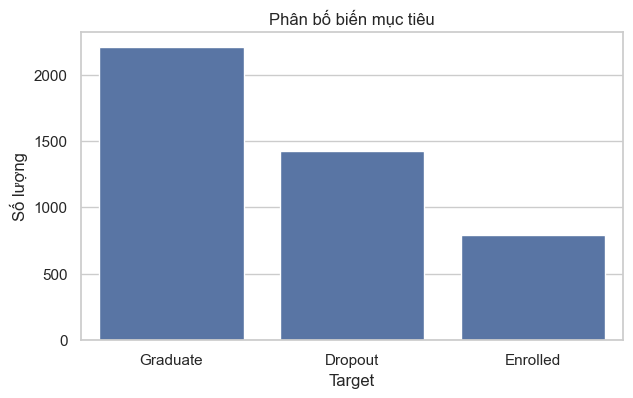

In [8]:
quality_df = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "n_unique": data.nunique(),
    "missing": data.isnull().sum(),
    "missing_pct": (data.isnull().mean() * 100).round(2)
}).sort_values(by=["missing", "n_unique"], ascending=[False, False])

display(quality_df)

print("Phân bố biến mục tiêu:")
display(data["target"].value_counts())
display((data["target"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(7, 4))
sns.countplot(x="target", data=data, order=data["target"].value_counts().index)
plt.title("Phân bố biến mục tiêu")
plt.xlabel("Target")
plt.ylabel("Số lượng")
plt.show()

### 6. Phân tích đơn biến

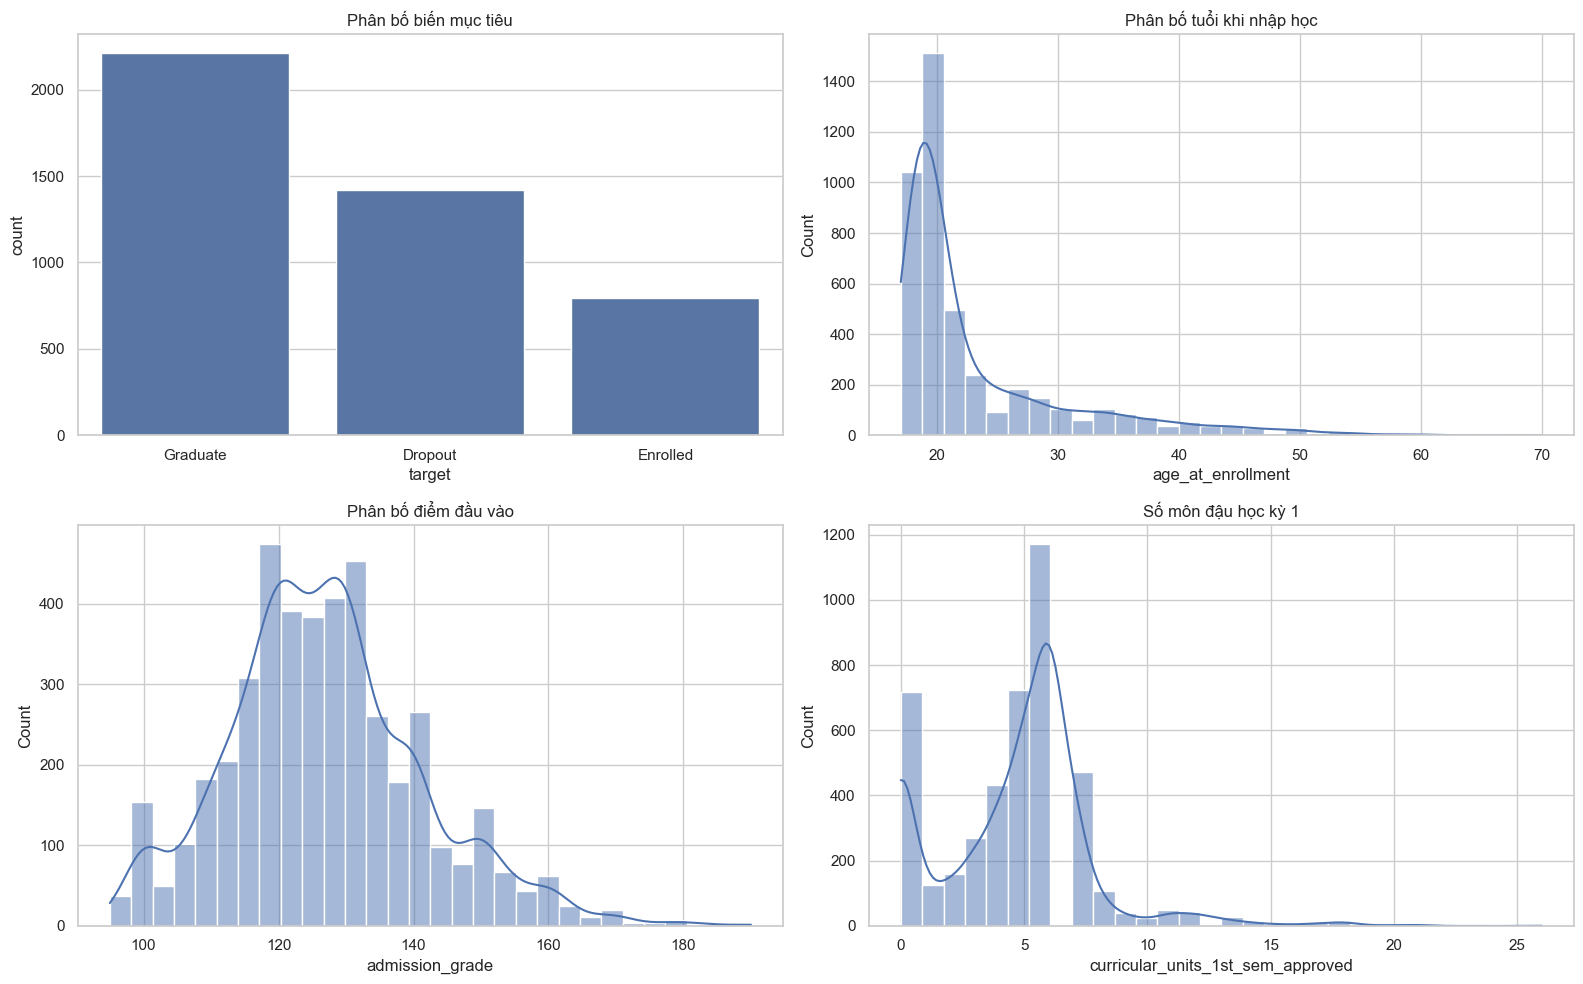

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(x=y, order=y.value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Phân bố biến mục tiêu")

if "age_at_enrollment" in data.columns:
    sns.histplot(data["age_at_enrollment"], bins=30, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title("Phân bố tuổi khi nhập học")

if "admission_grade" in data.columns:
    sns.histplot(data["admission_grade"], bins=30, kde=True, ax=axes[1, 0])
    axes[1, 0].set_title("Phân bố điểm đầu vào")

if "curricular_units_1st_sem_approved" in data.columns:
    sns.histplot(data["curricular_units_1st_sem_approved"], bins=30, kde=True, ax=axes[1, 1])
    axes[1, 1].set_title("Số môn đậu học kỳ 1")

plt.tight_layout()
plt.show()

### 6.1. Phân tích ngoại lai và giá trị bất thường

age_at_enrollment: 441 giá trị ngoại lai theo IQR, ngưỡng [10.00, 34.00]
admission_grade: 86 giá trị ngoại lai theo IQR, ngưỡng [92.55, 160.15]
curricular_units_1st_sem_grade: 726 giá trị ngoại lai theo IQR, ngưỡng [7.40, 17.00]
curricular_units_2nd_sem_grade: 877 giá trị ngoại lai theo IQR, ngưỡng [6.87, 17.21]


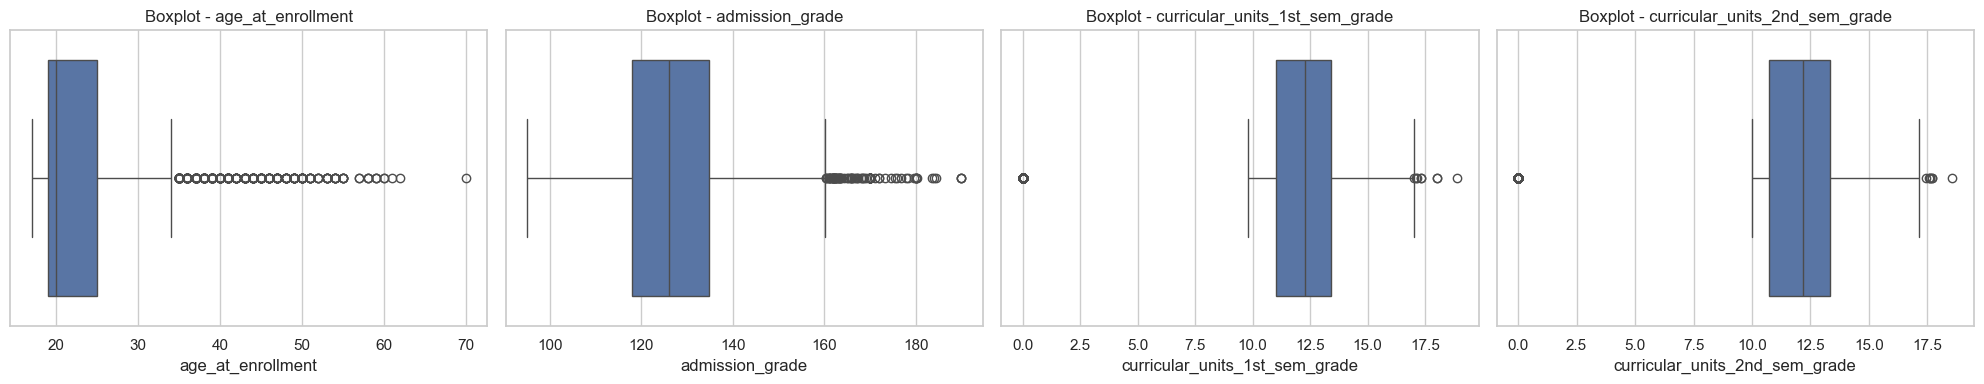

In [10]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()
    return count, lower, upper

check_cols = [
    "age_at_enrollment",
    "admission_grade",
    "curricular_units_1st_sem_grade",
    "curricular_units_2nd_sem_grade"
]

existing_check_cols = [col for col in check_cols if col in data.columns]

for col in existing_check_cols:
    count, lower, upper = iqr_outlier_count(data[col])
    print(f"{col}: {count} giá trị ngoại lai theo IQR, ngưỡng [{lower:.2f}, {upper:.2f}]")

if len(existing_check_cols) > 0:
    fig, axes = plt.subplots(1, len(existing_check_cols), figsize=(5 * len(existing_check_cols), 4))
    if len(existing_check_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, existing_check_cols):
        sns.boxplot(x=data[col], ax=ax)
        ax.set_title(f"Boxplot - {col}")

    plt.tight_layout()
    plt.show()

### 7. Phân tích đa biến

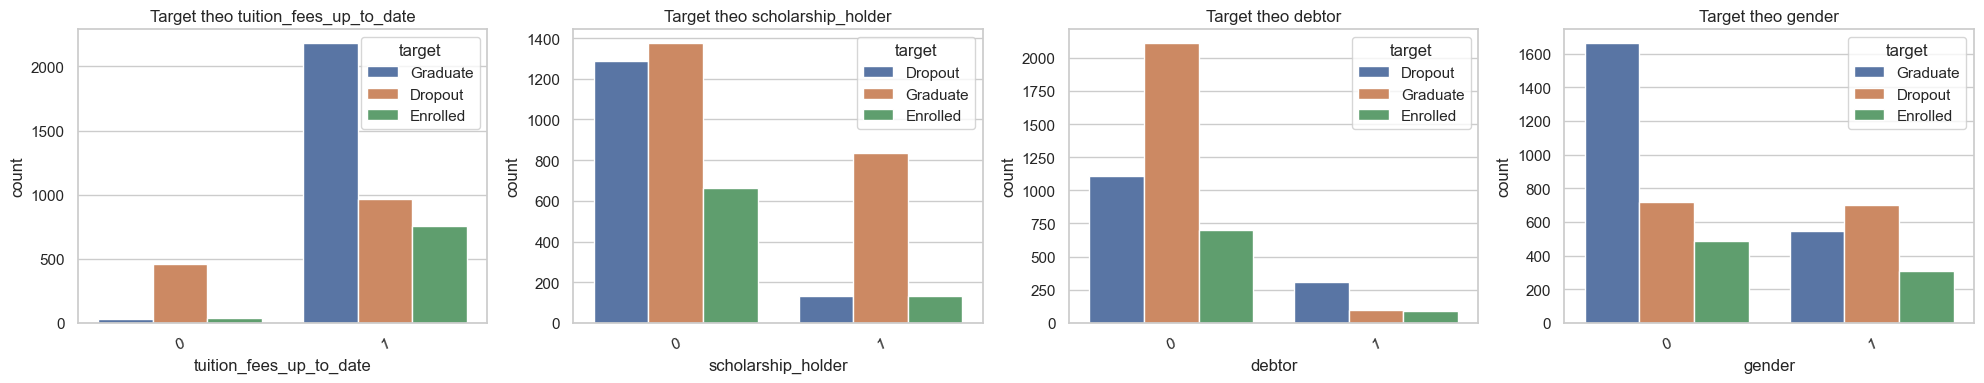

In [11]:
plot_cols = [
    "tuition_fees_up_to_date",
    "scholarship_holder",
    "debtor",
    "gender"
]

existing_plot_cols = [col for col in plot_cols if col in data.columns]

if len(existing_plot_cols) > 0:
    fig, axes = plt.subplots(1, len(existing_plot_cols), figsize=(5 * len(existing_plot_cols), 4))
    
    if len(existing_plot_cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, existing_plot_cols):
        sns.countplot(data=data, x=col, hue="target", ax=ax)
        ax.set_title(f"Target theo {col}")
        ax.tick_params(axis="x", rotation=20)
    
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy các cột để vẽ countplot theo target.")

### 7.1. Phân tích trung bình các biến học vụ theo từng nhóm kết quả học tập

In [12]:
important_cols = [
    "curricular_units_1st_sem_approved",
    "curricular_units_1st_sem_grade",
    "curricular_units_2nd_sem_approved",
    "curricular_units_2nd_sem_grade",
    "admission_grade",
    "age_at_enrollment"
]

existing_important_cols = [col for col in important_cols if col in eda_data.columns]

group_summary = eda_data.groupby("target")[existing_important_cols].mean().round(2)
display(group_summary)

,curricular_units_1st_sem_approved,curricular_units_1st_sem_grade,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,admission_grade,age_at_enrollment
target,,,,,,
Dropout,2.55,7.26,1.94,5.90,124.96,26.07
Enrolled,4.32,11.13,4.06,11.12,125.53,22.37
Graduate,6.23,12.64,6.18,12.70,128.79,21.78


### 7.2. Phân tích tình trạng học tập theo các yếu tố tài chính và hỗ trợ

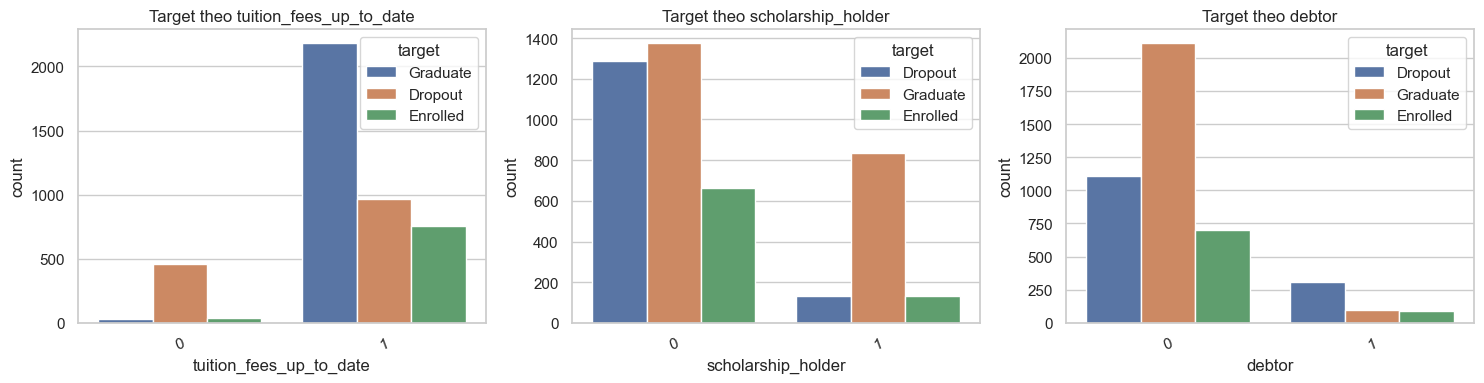

In [13]:
plot_cols = ["tuition_fees_up_to_date", "scholarship_holder", "debtor"]
existing_plot_cols = [col for col in plot_cols if col in eda_data.columns]

if len(existing_plot_cols) > 0:
    fig, axes = plt.subplots(1, len(existing_plot_cols), figsize=(5 * len(existing_plot_cols), 4))
    if len(existing_plot_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, existing_plot_cols):
        sns.countplot(data=eda_data, x=col, hue="target", ax=ax)
        ax.set_title(f"Target theo {col}")
        ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()

### 7.3. Phân tích target theo các nhóm thành tích học tập


Phân bố target theo sem1_approved_group:


target,Dropout,Enrolled,Graduate
sem1_approved_group,,,
0,79.39,9.89,10.72
1-3,61.87,30.22,7.91
4-6,18.05,20.46,61.50
7+,10.51,9.66,79.83


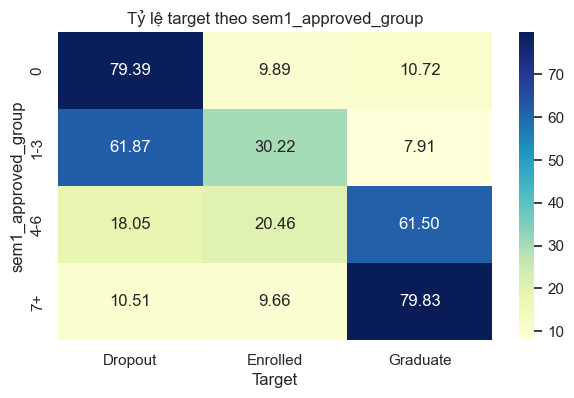


Phân bố target theo sem2_approved_group:


target,Dropout,Enrolled,Graduate
sem2_approved_group,,,
0,83.56,7.82,8.62
1-3,55.11,38.36,6.53
4-6,14.01,19.71,66.27
7+,8.22,9.62,82.16


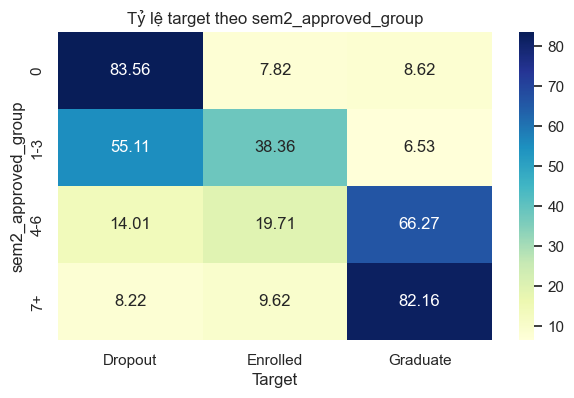


Phân bố target theo admission_grade_group:


target,Dropout,Enrolled,Graduate
admission_grade_group,,,
low,39.51,19.71,40.77
medium,31.02,21.01,47.97
high,29.34,14.99,55.68
very_high,28.56,16.05,55.39


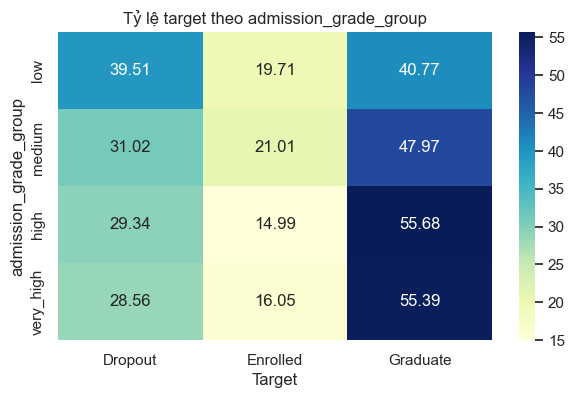

In [14]:
group_cols = [
    "sem1_approved_group",
    "sem2_approved_group",
    "admission_grade_group"
]

existing_group_cols = [col for col in group_cols if col in eda_data.columns]

for col in existing_group_cols:
    print(f"\nPhân bố target theo {col}:")
    table = pd.crosstab(eda_data[col], eda_data["target"], normalize="index") * 100
    display(table.round(2))

    plt.figure(figsize=(7, 4))
    sns.heatmap(table.round(2), annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title(f"Tỷ lệ target theo {col}")
    plt.ylabel(col)
    plt.xlabel("Target")
    plt.show()

### 8. Ma trận tương quan giữa các biến số

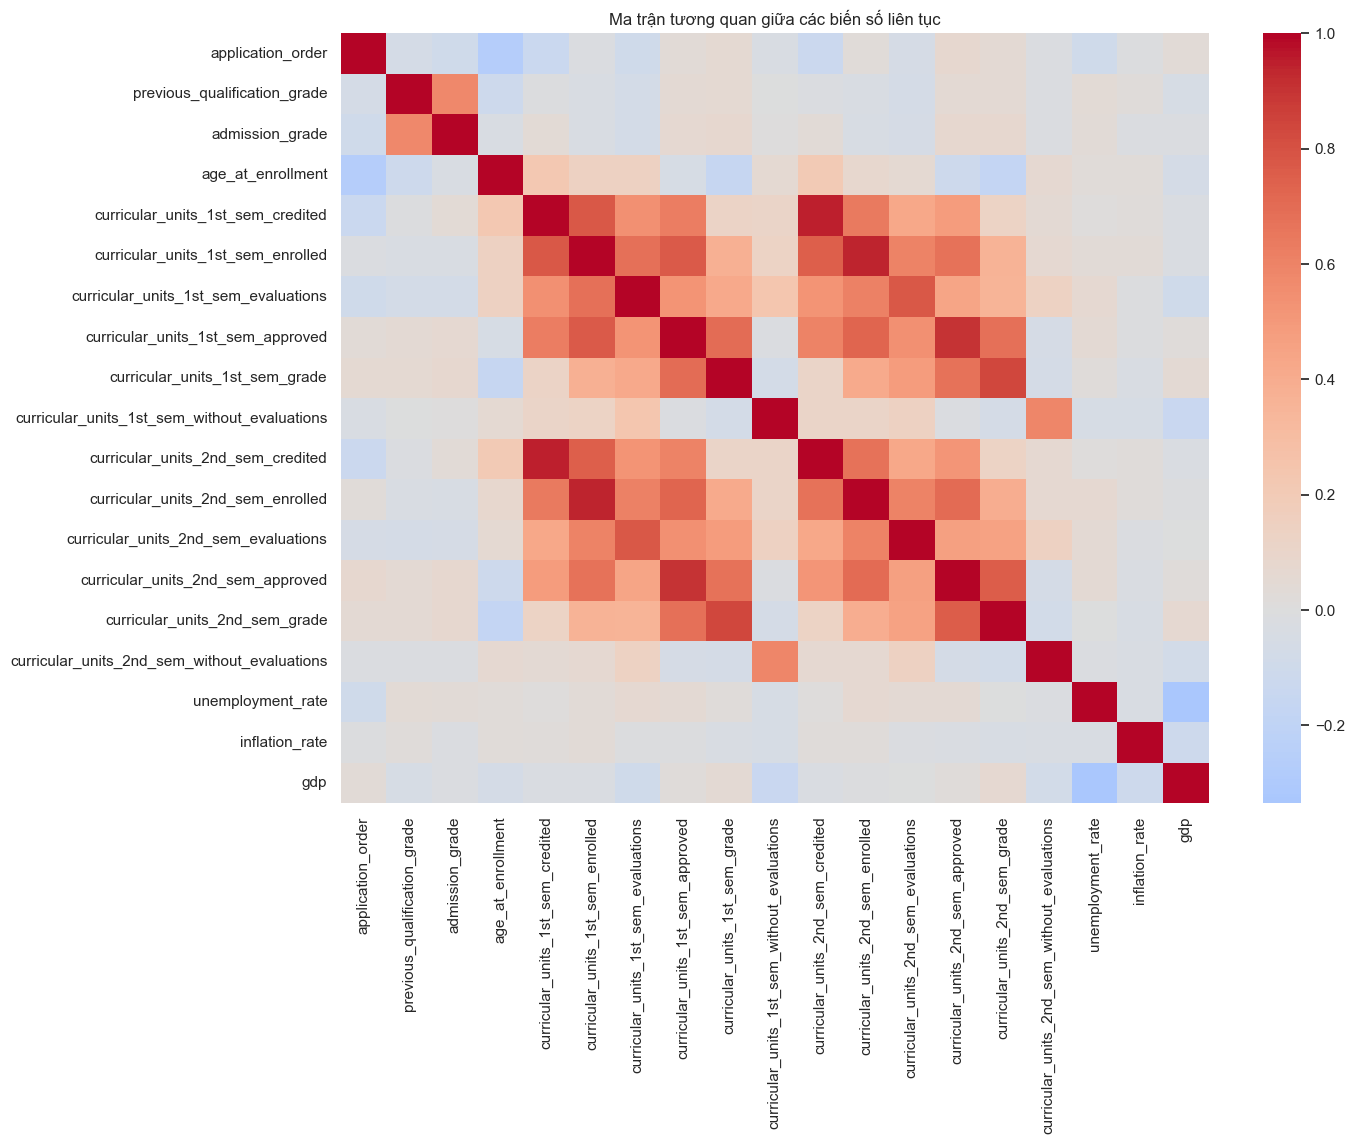

In [15]:
continuous_cols = [
    col for col in data.columns
    if col not in [
        "target",
        "marital_status",
        "application_mode",
        "course",
        "daytime_evening_attendance",
        "previous_qualification",
        "nacionality",
        "mothers_qualification",
        "fathers_qualification",
        "mothers_occupation",
        "fathers_occupation",
        "displaced",
        "educational_special_needs",
        "debtor",
        "tuition_fees_up_to_date",
        "gender",
        "scholarship_holder",
        "international"
    ]
]

continuous_cols = [col for col in continuous_cols if pd.api.types.is_numeric_dtype(data[col])]

plt.figure(figsize=(14, 10))
sns.heatmap(data[continuous_cols].corr(), cmap="coolwarm", center=0)
plt.title("Ma trận tương quan giữa các biến số liên tục")
plt.show()

## Bài toán 2: Phân tích kết hợp các đặc trưng liên quan đến Dropout và Graduate
### 8.1. Khai phá luật kết hợp từ dữ liệu sinh viên

In [16]:
rule_cols = [
    "age_group",
    "admission_grade_group",
    "sem1_approved_group",
    "sem2_approved_group",
    "sem1_grade_group",
    "sem2_grade_group",
    "tuition_fees_up_to_date",
    "scholarship_holder",
    "debtor",
    "target"
]

rule_cols = [col for col in rule_cols if col in eda_data.columns]
rule_data = eda_data[rule_cols].copy()

binary_cols = ["tuition_fees_up_to_date", "scholarship_holder", "debtor"]
for col in binary_cols:
    if col in rule_data.columns:
        rule_data[col] = rule_data[col].map({
            1: f"{col}_yes",
            0: f"{col}_no"
        })

rule_data["target"] = rule_data["target"].map(lambda x: f"target_{str(x).lower()}")

basket = pd.get_dummies(rule_data.astype(str))

freq_items = apriori(basket, min_support=0.05, use_colnames=True)
rules = association_rules(freq_items, metric="confidence", min_threshold=0.60)

rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ", ".join(sorted(list(x))))

dropout_rules = rules[
    rules["consequents_str"].str.contains("target_dropout", na=False)
].sort_values(by=["lift", "confidence", "support"], ascending=False)

graduate_rules = rules[
    rules["consequents_str"].str.contains("target_graduate", na=False)
].sort_values(by=["lift", "confidence", "support"], ascending=False)

print("Top luật cho target_dropout:")
display(dropout_rules[["antecedents_str", "consequents_str", "support", "confidence", "lift"]].head(10))

print("Top luật cho target_graduate:")
display(graduate_rules[["antecedents_str", "consequents_str", "support", "confidence", "lift"]].head(10))

Top luật cho target_dropout:


,antecedents_str,consequents_str,support,confidence,lift
13507,"debtor_debtor_no, scholarship_holder_scholarsh...","sem1_grade_group_low, sem2_grade_group_low, ta...",0.067812,0.606061,7.018880
13529,"scholarship_holder_scholarship_holder_no, sem1...","debtor_debtor_no, sem1_approved_group_0, sem2_...",0.067812,0.697674,6.920430
13533,"scholarship_holder_scholarship_holder_no, sem1...","debtor_debtor_no, sem1_grade_group_low, sem2_a...",0.067812,0.721154,6.875829
13534,"scholarship_holder_scholarship_holder_no, sem1...","debtor_debtor_no, sem1_approved_group_0, sem2_...",0.067812,0.677201,6.824457
13528,"scholarship_holder_scholarship_holder_no, sem1...","debtor_debtor_no, sem1_grade_group_low, sem2_g...",0.067812,0.733496,6.802909
12868,"scholarship_holder_scholarship_holder_no, sem1...","debtor_debtor_no, sem1_approved_group_0, targe...",0.067812,0.697674,6.709808
13496,"scholarship_holder_scholarship_holder_no, sem1...","debtor_debtor_no, sem1_approved_group_0, targe...",0.067812,0.697674,6.709808
12983,"scholarship_holder_scholarship_holder_no, sem1...","debtor_debtor_no, sem1_approved_group_0, targe...",0.068716,0.686230,6.599745
12803,"scholarship_holder_scholarship_holder_no, sem1...","debtor_debtor_no, sem1_approved_group_0, sem2_...",0.094033,0.659271,6.539495
10322,"scholarship_holder_scholarship_holder_no, sem1...","sem1_approved_group_0, sem2_grade_group_low, t...",0.115958,0.812995,6.480524


Top luật cho target_graduate:


,antecedents_str,consequents_str,support,confidence,lift
13278,"debtor_debtor_no, sem1_approved_group_7+, sem1...","sem2_approved_group_7+, sem2_grade_group_high,...",0.062613,0.628118,7.106889
11549,"sem1_approved_group_7+, sem1_grade_group_high,...","sem2_approved_group_7+, sem2_grade_group_high,...",0.065778,0.624464,7.065541
13266,"debtor_debtor_no, sem1_approved_group_7+, sem2...","sem1_grade_group_high, sem2_approved_group_7+,...",0.062613,0.694236,7.044262
11544,"sem1_approved_group_7+, sem2_grade_group_high,...","sem1_grade_group_high, sem2_approved_group_7+,...",0.065778,0.691211,7.013576
11581,"debtor_debtor_no, sem1_approved_group_7+, sem1...","sem2_approved_group_7+, sem2_grade_group_high,...",0.063065,0.618625,6.999484
13290,"debtor_debtor_no, sem1_approved_group_7+, sem1...","sem2_approved_group_7+, sem2_grade_group_high,...",0.062613,0.614191,6.985038
11545,"sem2_approved_group_7+, sem2_grade_group_high,...","sem1_approved_group_7+, sem1_grade_group_high,...",0.065778,0.624464,6.958757
13287,"sem1_approved_group_7+, sem2_grade_group_high,...","debtor_debtor_no, sem1_grade_group_high, sem2_...",0.062613,0.657957,6.930483
13267,"debtor_debtor_no, sem2_approved_group_7+, sem2...","sem1_approved_group_7+, sem1_grade_group_high,...",0.062613,0.621076,6.921011
11574,"debtor_debtor_no, sem1_approved_group_7+, sem2...","sem1_grade_group_high, sem2_approved_group_7+,...",0.063065,0.680488,6.904766


In [17]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

report_cols = ["antecedents_str", "consequents_str", "support", "confidence", "lift"]

dropout_rules_top = dropout_rules[report_cols].copy().head(5)
graduate_rules_top = graduate_rules[report_cols].copy().head(5)

dropout_rules_top["Rule_Group"] = "Dropout"
graduate_rules_top["Rule_Group"] = "Graduate"

rules_report = pd.concat([dropout_rules_top, graduate_rules_top], ignore_index=True)

rules_report = rules_report[["Rule_Group", "antecedents_str", "consequents_str", "support", "confidence", "lift"]]

rules_report["support"] = rules_report["support"].round(4)
rules_report["confidence"] = rules_report["confidence"].round(4)
rules_report["lift"] = rules_report["lift"].round(4)

rules_report.columns = ["Nhóm luật", "Antecedents", "Consequents", "Support", "Confidence", "Lift"]

display(rules_report)

,Nhóm luật,Antecedents,Consequents,Support,Confidence,Lift
0,Dropout,"debtor_debtor_no, scholarship_holder_scholarship_holder_no, sem1_approved_group_0, sem2_approved_group_0","sem1_grade_group_low, sem2_grade_group_low, target_target_dropout, tuition_fees_up_to_date_tuition_fees_up_to_date_yes",0.0678,0.6061,7.0189
1,Dropout,"scholarship_holder_scholarship_holder_no, sem1_grade_group_low, sem2_approved_group_0, tuition_fees_up_to_date_tuition_fees_up_to_date_yes","debtor_debtor_no, sem1_approved_group_0, sem2_grade_group_low, target_target_dropout",0.0678,0.6977,6.9204
2,Dropout,"scholarship_holder_scholarship_holder_no, sem1_approved_group_0, sem2_grade_group_low, tuition_fees_up_to_date_tuition_fees_up_to_date_yes","debtor_debtor_no, sem1_grade_group_low, sem2_approved_group_0, target_target_dropout",0.0678,0.7212,6.8758
3,Dropout,"scholarship_holder_scholarship_holder_no, sem1_grade_group_low, sem2_grade_group_low, tuition_fees_up_to_date_tuition_fees_up_to_date_yes","debtor_debtor_no, sem1_approved_group_0, sem2_approved_group_0, target_target_dropout",0.0678,0.6772,6.8245
4,Dropout,"scholarship_holder_scholarship_holder_no, sem1_approved_group_0, sem2_approved_group_0, tuition_fees_up_to_date_tuition_fees_up_to_date_yes","debtor_debtor_no, sem1_grade_group_low, sem2_grade_group_low, target_target_dropout",0.0678,0.7335,6.8029
5,Graduate,"debtor_debtor_no, sem1_approved_group_7+, sem1_grade_group_high, tuition_fees_up_to_date_tuition_fees_up_to_date_yes","sem2_approved_group_7+, sem2_grade_group_high, target_target_graduate",0.0626,0.6281,7.1069
6,Graduate,"sem1_approved_group_7+, sem1_grade_group_high, tuition_fees_up_to_date_tuition_fees_up_to_date_yes","sem2_approved_group_7+, sem2_grade_group_high, target_target_graduate",0.0658,0.6245,7.0655
7,Graduate,"debtor_debtor_no, sem1_approved_group_7+, sem2_grade_group_high, tuition_fees_up_to_date_tuition_fees_up_to_date_yes","sem1_grade_group_high, sem2_approved_group_7+, target_target_graduate",0.0626,0.6942,7.0443
8,Graduate,"sem1_approved_group_7+, sem2_grade_group_high, tuition_fees_up_to_date_tuition_fees_up_to_date_yes","sem1_grade_group_high, sem2_approved_group_7+, target_target_graduate",0.0658,0.6912,7.0136
9,Graduate,"debtor_debtor_no, sem1_approved_group_7+, sem1_grade_group_high","sem2_approved_group_7+, sem2_grade_group_high, target_target_graduate",0.0631,0.6186,6.9995


## Bài toán 1: Phân loại tình trạng học tập của sinh viên
### 9. Chia dữ liệu train và test, xây dựng pipeline tiền xử lý

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

categorical_features = [
    "marital_status",
    "application_mode",
    "course",
    "daytime_evening_attendance",
    "previous_qualification",
    "nacionality",
    "mothers_qualification",
    "fathers_qualification",
    "mothers_occupation",
    "fathers_occupation",
    "displaced",
    "educational_special_needs",
    "debtor",
    "tuition_fees_up_to_date",
    "gender",
    "scholarship_holder",
    "international"
]

categorical_features = [col for col in categorical_features if col in X.columns]
numeric_features = [col for col in X.columns if col not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test :", X_test.shape)
print("Biến số:", numeric_features)
print("Biến phân loại:", categorical_features)

print("\nPhân bố target trong train:")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("Phân bố target trong test:")
display((y_test.value_counts(normalize=True) * 100).round(2))

Kích thước X_train: (3539, 36)
Kích thước X_test : (885, 36)
Biến số: ['application_order', 'previous_qualification_grade', 'admission_grade', 'age_at_enrollment', 'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled', 'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations', 'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled', 'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp']
Biến phân loại: ['marital_status', 'application_mode', 'course', 'daytime_evening_attendance', 'previous_qualification', 'nacionality', 'mothers_qualification', 'fathers_qualification', 'mothers_occupation', 'fathers_occupation', 'displaced', 'educational_special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scho

target
Graduate    49.93
Dropout     32.13
Enrolled    17.94
Name: proportion, dtype: float64

Phân bố target trong test:


target
Graduate    49.94
Dropout     32.09
Enrolled    17.97
Name: proportion, dtype: float64

### 10. Xây dựng các mô hình phân loại

In [19]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    )
}

def evaluate_multiclass_model(name, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    }
    
    y_prob = None
    if hasattr(pipe.named_steps["classifier"], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)
        classes = pipe.named_steps["classifier"].classes_
        y_test_bin = label_binarize(y_test, classes=classes)
        result["ROC_AUC_OVR_weighted"] = roc_auc_score(
            y_test_bin, y_prob, multi_class="ovr", average="weighted"
        )
    else:
        result["ROC_AUC_OVR_weighted"] = np.nan
    
    return pipe, y_pred, y_prob, result

print("Đã khởi tạo xong các mô hình.")

Đã khởi tạo xong các mô hình.


### 11. Huấn luyện và so sánh các mô hình

In [20]:
trained_models = {}
results = []

for name, model in models.items():
    pipe, y_pred, y_prob, result = evaluate_multiclass_model(
        name, model, X_train, X_test, y_train, y_test
    )
    trained_models[name] = {
        "pipeline": pipe,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    results.append(result)

results_df = pd.DataFrame(results).sort_values(by="F1_macro", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_OVR_weighted
0,Random Forest,0.743503,0.703287,0.706903,0.699633,0.751291,0.900668
1,Logistic Regression,0.725424,0.696859,0.700709,0.688517,0.738401,0.896581
2,Decision Tree,0.665537,0.668581,0.659143,0.639635,0.687192,0.826099


### 12. Chọn mô hình tốt nhất và đánh giá chi tiết

Mô hình tốt nhất: Random Forest

              precision    recall  f1-score   support

     Dropout       0.81      0.69      0.74       284
    Enrolled       0.45      0.60      0.51       159
    Graduate       0.86      0.83      0.84       442

    accuracy                           0.74       885
   macro avg       0.70      0.71      0.70       885
weighted avg       0.77      0.74      0.75       885



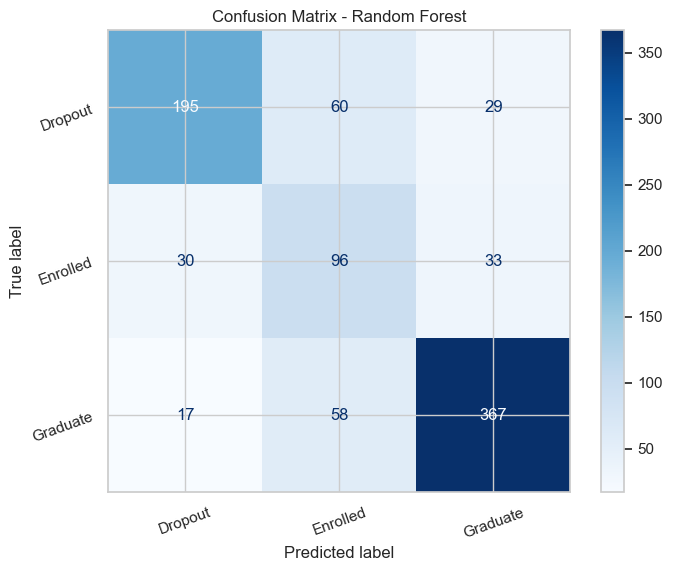

In [21]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]["pipeline"]
best_pred = trained_models[best_model_name]["y_pred"]

print("Mô hình tốt nhất:", best_model_name)
print()
print(classification_report(y_test, best_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xticks(rotation=20)
plt.yticks(rotation=20)
plt.show()

### 12.1. Phân tích các trường hợp dự đoán sai

In [22]:
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["pred"] = best_pred

misclassified = error_df[error_df["actual"] != error_df["pred"]].copy()

print("Tổng số trường hợp dự đoán sai:", len(misclassified))
print("\nMa trận actual vs pred của các trường hợp sai:")
display(pd.crosstab(misclassified["actual"], misclassified["pred"]))

important_cols = [
    "curricular_units_1st_sem_approved",
    "curricular_units_1st_sem_grade",
    "curricular_units_2nd_sem_approved",
    "curricular_units_2nd_sem_grade",
    "admission_grade",
    "age_at_enrollment"
]

existing_cols = [col for col in important_cols if col in misclassified.columns]

if len(existing_cols) > 0:
    print("\nTrung bình các biến học vụ trong các trường hợp dự đoán sai:")
    display(misclassified.groupby(["actual", "pred"])[existing_cols].mean().round(2))

Tổng số trường hợp dự đoán sai: 227

Ma trận actual vs pred của các trường hợp sai:


pred,Dropout,Enrolled,Graduate
actual,,,
Dropout,0,60,29
Enrolled,30,0,33
Graduate,17,58,0



Trung bình các biến học vụ trong các trường hợp dự đoán sai:


curricular_units_1st_sem_approved  \
actual   pred                                          
Dropout  Enrolled                               3.78   
         Graduate                               6.24   
Enrolled Dropout                                2.53   
         Graduate                               5.61   
Graduate Dropout                                2.71   
         Enrolled                               4.83   

                   curricular_units_1st_sem_grade  \
actual   pred                                       
Dropout  Enrolled                           11.55   
         Graduate                           12.73   
Enrolled Dropout                             7.83   
         Graduate                           12.02   
Graduate Dropout                             6.85   
         Enrolled                           11.93   

                   curricular_units_2nd_sem_approved  \
actual   pred                                          
Dropout  Enrolled                               3.27   
         Graduate                               6.28   
Enrolled Dropout                                1.83   
         Graduate                               5.79   
Graduate Dropout                                2.41   
         Enrolled                               4.71   

                   curricular_units_2nd_sem_grade  admission_grade  \
actual   pred                                                        
Dropout  Enrolled                           11.70           123.43   
         Graduate                           12.76           130.19   
Enrolled Dropout                             7.00           124.64   
         Graduate                           11.86           126.35   
Graduate Dropout                             6.63           131.58   
         Enrolled                           12.16           123.56   

                   age_at_enrollment  
actual   pred                         
Dropout  Enrolled              23.93  
         Graduate              23.28  
Enrolled Dropout               24.70  
         Graduate              20.03  
Graduate Dropout               23.41  
         Enrolled              20.88

### 13. Phân tích mức độ ảnh hưởng của các thuộc tính

,Feature,Importance
13,num__curricular_units_2nd_sem_approved,0.132549
14,num__curricular_units_2nd_sem_grade,0.096936
7,num__curricular_units_1st_sem_approved,0.086121
8,num__curricular_units_1st_sem_grade,0.067908
237,cat__tuition_fees_up_to_date_1,0.045455
12,num__curricular_units_2nd_sem_evaluations,0.043363
6,num__curricular_units_1st_sem_evaluations,0.039483
236,cat__tuition_fees_up_to_date_0,0.033505
3,num__age_at_enrollment,0.030760
2,num__admission_grade,0.021729


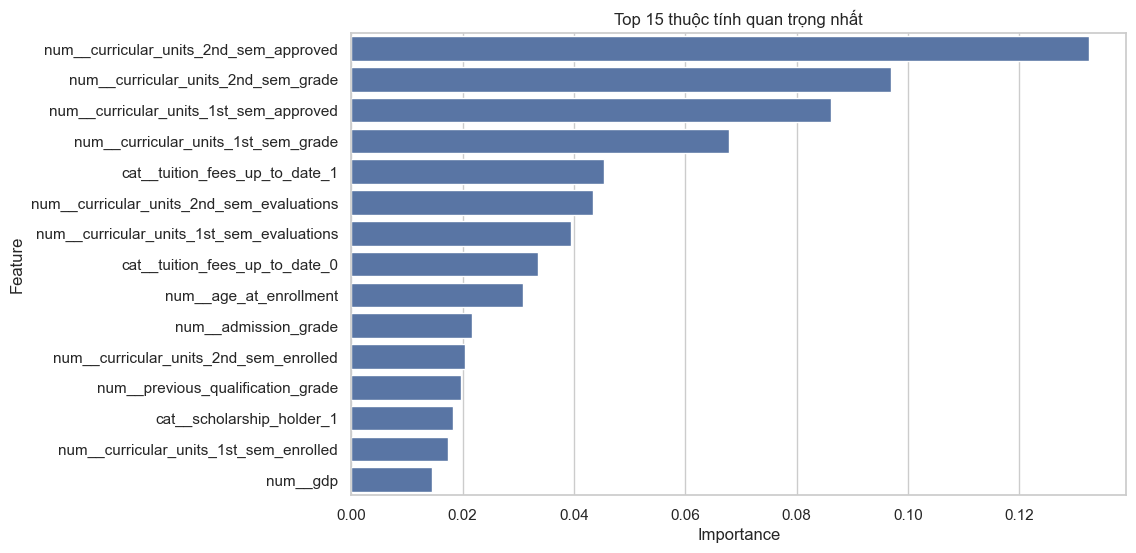

In [23]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

if best_model_name in ["Decision Tree", "Random Forest"]:
    importances = best_model.named_steps["classifier"].feature_importances_
    feat_imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    display(feat_imp.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp.head(15), x="Importance", y="Feature")
    plt.title("Top 15 thuộc tính quan trọng nhất")
    plt.show()

elif best_model_name == "Logistic Regression":
    coef = best_model.named_steps["classifier"].coef_
    avg_abs_coef = np.mean(np.abs(coef), axis=0)

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": avg_abs_coef
    }).sort_values(by="Importance", ascending=False)

    display(coef_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df.head(15), x="Importance", y="Feature")
    plt.title("Top 15 thuộc tính có ảnh hưởng lớn nhất")
    plt.show()

### 14. Trả lời câu hỏi khai phá dữ liệu và tổng hợp các bài toán trên dataset 2

**Câu hỏi 1: Những yếu tố nào ảnh hưởng nhiều nhất đến tình trạng học tập của sinh viên?**  
Dựa trên kết quả phân tích thống kê mô tả, phân tích theo nhóm, phân tích đa biến, khai phá luật kết hợp và mức độ quan trọng của thuộc tính từ mô hình tốt nhất, có thể thấy tình trạng học tập của sinh viên chịu ảnh hưởng mạnh bởi các nhóm yếu tố sau:
- kết quả học tập trong năm nhất, đặc biệt là số môn đạt và điểm trung bình ở học kỳ 1 và học kỳ 2;
- tình trạng đóng học phí đúng hạn;
- số lần tham gia đánh giá ở học kỳ 1 và học kỳ 2;
- điểm đầu vào và tuổi khi nhập học;
- một số mẫu kết hợp giữa năng lực học tập và điều kiện tài chính.

Kết quả từ mô hình Random Forest cho thấy các thuộc tính quan trọng nhất gồm: **`curricular_units_2nd_sem_approved`**, **`curricular_units_2nd_sem_grade`**, **`curricular_units_1st_sem_approved`**, **`curricular_units_1st_sem_grade`**, **`tuition_fees_up_to_date`**, **`curricular_units_2nd_sem_evaluations`**, **`curricular_units_1st_sem_evaluations`**, **`age_at_enrollment`** và **`admission_grade`**.  
Ngoài ra, phần khai phá luật kết hợp cũng cho thấy một số tổ hợp đặc trưng thường xuất hiện cùng với nhóm **Dropout** hoặc **Graduate**. Cụ thể, các luật mạnh cho nhóm **Dropout** thường gắn với các đặc điểm như **không có học bổng**, **số môn đạt học kỳ 1 bằng 0**, **điểm học kỳ thấp** và **kết quả học tập yếu ở cả hai học kỳ**. Ngược lại, các luật mạnh cho nhóm **Graduate** thường gắn với **số môn đạt cao ở cả hai học kỳ**, **điểm học kỳ cao** và **không có tình trạng nợ học phí**.

**Câu hỏi 2: Có thể xây dựng mô hình dự đoán kết quả học tập của sinh viên đủ tốt để hỗ trợ nhà trường hay không?**  
Dựa trên kết quả thực nghiệm, mô hình tốt nhất là **Random Forest** với các chỉ số:
- Accuracy = **0.743503**
- Precision_macro = **0.703287**
- Recall_macro = **0.706903**
- F1_macro = **0.699633**
- F1_weighted = **0.751291**
- ROC_AUC_OVR_weighted = **0.900668**

So với hai mô hình còn lại, Random Forest cho kết quả tốt nhất trên hầu hết các chỉ số đánh giá, đặc biệt là **F1_macro** và **ROC_AUC_OVR_weighted**. Điều này cho thấy mô hình có khả năng phân biệt khá tốt giữa ba nhóm sinh viên: **Dropout**, **Enrolled** và **Graduate**.  
Vì vậy, có thể kết luận rằng bài toán dự đoán kết quả học tập của sinh viên là **khá khả thi**. Mô hình Random Forest có thể hỗ trợ nhà trường trong việc nhận diện sớm sinh viên có nguy cơ bỏ học hoặc học tập không ổn định để đưa ra các biện pháp hỗ trợ phù hợp.

**Tổng hợp các bài toán đã thực hiện trên dataset 2**  
Trên bộ dữ liệu Predict Students’ Dropout and Academic Success, đề tài đã khai thác theo **hai hướng bài toán chính**:

**Bài toán 1: Phân loại (Classification)**  
Xây dựng mô hình dự đoán tình trạng học tập cuối cùng của sinh viên thuộc ba nhóm Dropout, Enrolled và Graduate, trong đó Random Forest cho kết quả tốt nhất trong thực nghiệm hiện tại.

**Bài toán 2: Phân tích kết hợp (Association Analysis)**  
Khai phá luật kết hợp từ dữ liệu sinh viên để tìm ra các tổ hợp đặc trưng thường xuất hiện cùng với nhóm Dropout hoặc Graduate. Kết quả cho thấy tình trạng học tập không phụ thuộc vào một yếu tố đơn lẻ mà gắn với sự kết hợp giữa **kết quả học tập năm nhất**, **tình trạng học phí**, **học bổng** và một số đặc điểm đầu vào của sinh viên.

**Kết luận chung cho dataset 2**  
Như vậy, dataset 2 không chỉ được sử dụng cho **bài toán phân loại** nhằm dự đoán tình trạng học tập của sinh viên, mà còn được khai phá theo hướng **phân tích kết hợp** để rút ra các quy luật và mẫu dữ liệu đặc trưng liên quan đến Dropout và Graduate.

In [24]:
results_df.to_csv("student_model_comparison_results.csv", index=False)
print("Đã lưu file student_model_comparison_results.csv")
results_df

Đã lưu file student_model_comparison_results.csv


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_OVR_weighted
0,Random Forest,0.743503,0.703287,0.706903,0.699633,0.751291,0.900668
1,Logistic Regression,0.725424,0.696859,0.700709,0.688517,0.738401,0.896581
2,Decision Tree,0.665537,0.668581,0.659143,0.639635,0.687192,0.826099


### 15. Kết luận tạm thời

Trong notebook này, bộ dữ liệu Predict Students' Dropout and Academic Success đã được khai phá theo hướng không chỉ xây dựng mô hình học máy mà còn rút ra các tri thức từ dữ liệu.  
Các bước thực hiện bao gồm:
- kiểm tra chất lượng dữ liệu,
- tiền xử lý và rút trích đặc trưng phục vụ khai phá,
- phân tích thống kê mô tả,
- phân tích đơn biến và đa biến,
- phân tích theo nhóm sinh viên,
- khai phá luật kết hợp,
- xây dựng và đánh giá nhiều mô hình phân loại.

Từ quá trình trên, có thể rút ra một số tri thức quan trọng:
- kết quả học tập trong năm nhất là nhóm yếu tố ảnh hưởng mạnh nhất đến tình trạng học tập sau này;
- tình trạng học phí và một số yếu tố tài chính có liên quan rõ rệt đến nguy cơ bỏ học;
- sinh viên có số môn đạt thấp, điểm học kỳ thấp và thiếu ổn định trong hai học kỳ đầu có nguy cơ rơi vào nhóm Dropout cao hơn rõ rệt;
- ngược lại, sinh viên có số môn đạt cao, điểm học kỳ cao và không có nợ học phí thường xuất hiện trong nhóm Graduate;
- mô hình Random Forest cho kết quả tốt nhất, cho thấy dữ liệu hiện tại có thể hỗ trợ khá tốt cho bài toán dự đoán và nhận diện sớm sinh viên có nguy cơ bỏ học.

Kết quả này là cơ sở để tiếp tục hoàn thiện báo cáo cuối kỳ theo hướng khai phá dữ liệu và ứng dụng thực tế trong công tác quản lý và hỗ trợ sinh viên.